In [1]:
import os
import random
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2025-04-15 19:37:07.045960: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-15 19:37:07.242468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744709827.341682   19352 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744709827.371416   19352 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744709827.545719   19352 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import os

# Base directory where data has been split into train/test
dst_dir = "Data/Task_01/"

# Define the splits and classes
splits = ["Train_Dir", "Test_dir"]
classes = ["rust", "no rust"]

# Loop through each split and class, and print the file count
for split in splits:
    print(f"--- {split.upper()} ---")
    for cls in classes:
        dir_path = os.path.join(dst_dir, split, cls)
        if os.path.exists(dir_path):
            file_list = os.listdir(dir_path)
            num_files = len(file_list)
            print(f"Directory '{dir_path}' exists with {num_files} files.")
        else:
            print(f"Directory '{dir_path}' does NOT exist.")
    print() 


--- TRAIN_DIR ---
Directory 'Data/Task_01/Train_Dir/rust' exists with 14 files.
Directory 'Data/Task_01/Train_Dir/no rust' exists with 15 files.

--- TEST_DIR ---
Directory 'Data/Task_01/Test_dir/rust' exists with 11 files.
Directory 'Data/Task_01/Test_dir/no rust' exists with 15 files.



In [16]:
# Section 2: Build and Train Simple CNN Model

# Image settings
img_height, img_width = 330, 330
batch_size = 20

# Data generators with augmentation for training
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dst_dir, "Train_Dir"),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dst_dir, "Test_dir"),
    target_size=(img_height, img_width),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# Build a simple CNN model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Train the CNN model
history_cnn = cnn_model.fit(train_generator, epochs=20)
cnn_model.save("Data/cnn_model.h5")

Found 29 images belonging to 2 classes.
Found 26 images belonging to 2 classes.


/home/admin/Documents/Applied_Machine_Learning/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 328, 328, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 164, 164, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 162, 162, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 81, 81, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 419904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │    26,873,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,893,377 (102.59 MB)

 Trainable params: 26,893,377 (102.59 MB)

 Non-trainable params: 0 (0.00 B)

/home/admin/Documents/Applied_Machine_Learning/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 800ms/step - accuracy: 0.5070 - loss: 12.0006
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5052 - loss: 6.0017 
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4559 - loss: 4.2932
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5615 - loss: 1.1634 
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7264 - loss: 0.5974 
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6271 - loss: 0.6229
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5160 - loss: 0.8143
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5160 - loss: 0.8431
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5908 - loss: 0.6441 
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6731 - loss: 0.6144
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8017 - loss: 0.4999 
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8287 - loss

In [4]:
# Section 3: Evaluate Simple CNN on Test Set

from sklearn.metrics import accuracy_score, classification_report

# Predict on test set
test_generator.reset()
predictions = cnn_model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# True classes
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Accuracy and report
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"CNN Test Accuracy: {accuracy:.2f}")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN Test Accuracy: 0.81
              precision    recall  f1-score   support

     no rust       0.78      0.93      0.85        15
        rust       0.88      0.64      0.74        11

    accuracy                           0.81        26
   macro avg       0.83      0.78      0.79        26
weighted avg       0.82      0.81      0.80        26



In [18]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
img_height, img_width = 330, 330
batch_size = 16

# Create data generators with ResNet50-specific preprocessing
resnet_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    os.path.join(dst_dir, "Train_Dir"),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

resnet_test_generator = resnet_test_datagen.flow_from_directory(
    os.path.join(dst_dir, "Test_dir"),
    target_size=(img_height, img_width),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# Load the ResNet50 base model without the top layers and with ImageNet weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add a custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create the full model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile with a low learning rate
resnet_model.compile(optimizer=Adam(learning_rate=0.01),
                     loss='binary_crossentropy', 
                     metrics=['accuracy'])

resnet_model.summary()

# Train the model (using 10 epochs as per the assessment instructions)
history_resnet = resnet_model.fit(resnet_train_generator, epochs=30)

# Optionally, save the trained model
resnet_model.save("Data/resnet_model.h5")


Found 29 images belonging to 2 classes.
Found 26 images belonging to 2 classes.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 330, 330,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 336, 336,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 165, 165,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 165, 165,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 165, 165,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 167, 167,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 83, 83,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 83, 83,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 83, 83,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 83, 83,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 83, 83,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 83, 83,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 83, 83,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 83, 83,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 83, 83,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 83, 83,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 83, 83,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 270,593 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/30


/home/admin/Documents/Applied_Machine_Learning/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6649 - loss: 0.6378
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4907 - loss: 7.8320
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4960 - loss: 2.1275
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8568 - loss: 0.4286
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8017 - loss: 0.6931
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9562 - loss: 0.1466
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0080
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 1.0000 - loss: 0.0282
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - loss: 0.0065
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 1.0000 - loss: 0.0043
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.0026
Epoch 13

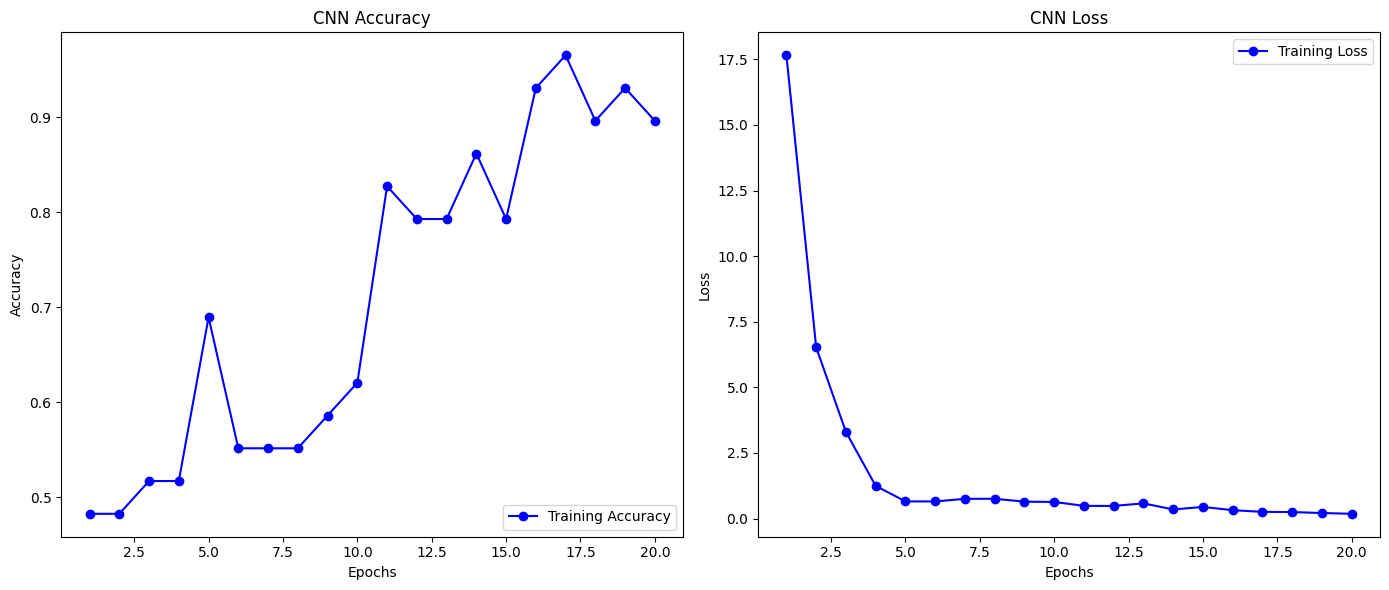

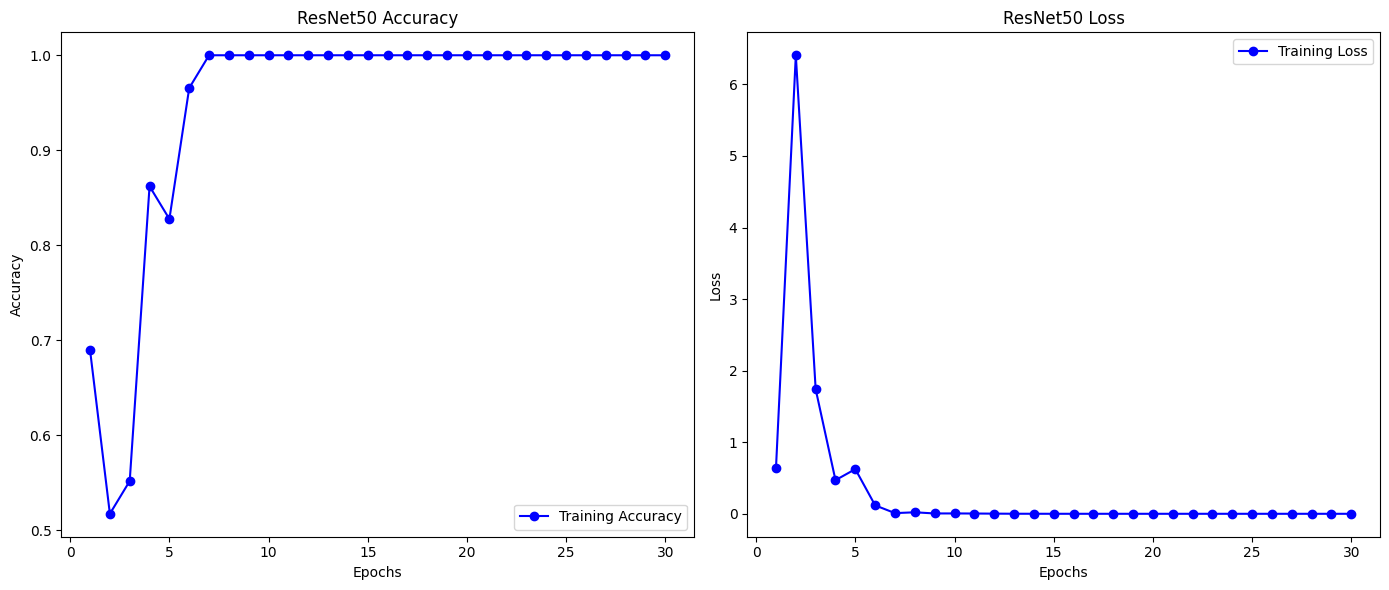

In [19]:
def plot_model_history(history, model_name="Model"):
    # Get metric lists from history
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    
    epochs = range(1, len(acc) + 1)
    
    # Create one figure with two subplots
    plt.figure(figsize=(14, 6))
    
    # Subplot for Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    if val_acc:
        plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    # Subplot for Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_metrics.png')
    plt.show()

# Plot the training history for both models
plot_model_history(history_cnn, model_name="CNN")

plot_model_history(history_resnet, model_name="ResNet50")


In [20]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate on the test set with the ResNet50 generator
resnet_test_generator.reset()
resnet_preds = resnet_model.predict(resnet_test_generator)
resnet_pred_classes = (resnet_preds > 0.5).astype(int).flatten()

# True class labels and class names
true_classes = resnet_test_generator.classes
class_labels = list(resnet_test_generator.class_indices.keys())

# Calculate accuracy and print the classification report
resnet_accuracy = accuracy_score(true_classes, resnet_pred_classes)
print(f"ResNet50 Test Accuracy: {resnet_accuracy:.2f}")
print(classification_report(true_classes, resnet_pred_classes, target_names=class_labels))

/home/admin/Documents/Applied_Machine_Learning/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
ResNet50 Test Accuracy: 0.81
              precision    recall  f1-score   support

     no rust       1.00      0.67      0.80        15
        rust       0.69      1.00      0.81        11

    accuracy                           0.81        26
   macro avg       0.84      0.83      0.81        26
weighted avg       0.87      0.81      0.81        26



In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input  # for proper ResNet processing

# Directories
test_dir = "Data/Task_01/Test_dir"
cnn_out_dir = "Data/Task_01/cnn_test"
resnet_out_dir = "Data/Task_01/resnet50_test"
os.makedirs(cnn_out_dir, exist_ok=True)
os.makedirs(resnet_out_dir, exist_ok=True)

# Use ImageDataGenerator to load test images (rescaling for CNN)
datagen = ImageDataGenerator(rescale=1./255)
generator = datagen.flow_from_directory(
    test_dir,
    target_size=(330, 330),
    batch_size=1,
    class_mode='binary',
    shuffle=True
)

# Collect 10 images per class (labels 0: "no rust", 1: "rust")
images, labels = [], []
counts = {0: 0, 1: 0}
while min(counts.values()) < 10:
    img_batch, label_batch = next(generator)
    lbl = int(label_batch[0])
    if counts[lbl] < 10:
        images.append(img_batch[0])
        labels.append(lbl)
        counts[lbl] += 1
images = np.array(images)
labels = np.array(labels)

# Get predictions from CNN model
cnn_preds = (cnn_model.predict(images) > 0.5).astype(int).reshape(-1)

# Since images are already scaled [0,1], we convert them back to [0,255] before applying preprocess_input.
images_resnet = preprocess_input(images.copy() * 255)
resnet_preds = (resnet_model.predict(images_resnet) > 0.5).astype(int).reshape(-1)

def save_images_with_labels(model_name, out_dir, imgs, true_labels, preds):
    for i, (img, t, p) in enumerate(zip(imgs, true_labels, preds)):
        plt.imshow(img)
        plt.title(f'{model_name} - True: {"rust" if t==1 else "no rust"} | Pred: {"rust" if p==1 else "no rust"}')
        plt.axis('off')
        plt.savefig(os.path.join(out_dir, f'{model_name}_{i}.png'))
        plt.close()

# Save images with labels for both models
save_images_with_labels("CNN", cnn_out_dir, images, labels, cnn_preds)
save_images_with_labels("ResNet50", resnet_out_dir, images, labels, resnet_preds)

def create_classification_table(model_name, out_dir, true_labels, preds):
    df = pd.DataFrame({
        "Image": [f"{model_name}_{i}.png" for i in range(len(true_labels))],
        "True": ["rust" if l==1 else "no rust" for l in true_labels],
        "Pred": ["rust" if p==1 else "no rust" for p in preds]
    })
    accuracy = (true_labels == preds).mean() * 100
    print(f"{model_name} Accuracy: {accuracy:.2f}%")
    csv_path = os.path.join(out_dir, f"{model_name}_results.csv")
    df.to_csv(csv_path, index=False)
    return df

# Create classification tables
create_classification_table("CNN", cnn_out_dir, labels, cnn_preds)
create_classification_table("ResNet50", resnet_out_dir, labels, resnet_preds)


Found 26 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
CNN Accuracy: 70.00%
ResNet50 Accuracy: 90.00%


,Image,True,Pred
0,ResNet50_0.png,rust,rust
1,ResNet50_1.png,no rust,no rust
2,ResNet50_2.png,no rust,rust
3,ResNet50_3.png,no rust,no rust
4,ResNet50_4.png,no rust,no rust
5,ResNet50_5.png,no rust,no rust
6,ResNet50_6.png,no rust,no rust
7,ResNet50_7.png,no rust,no rust
8,ResNet50_8.png,no rust,rust
9,ResNet50_9.png,no rust,no rust
